In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import Image

In [14]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Define paths
base_dir = '../data/DAWN_processed'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Define classes (weather conditions)
classes = ['Fog', 'Rain', 'Snow', 'Sand']

# Define parameters
img_height, img_width = 64, 64  # Reduced image size for RNN compatibility
batch_size = 32
epochs = 20
learning_rate = 0.001
hidden_size = 128
num_layers = 2

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [15]:
# Data transformations
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=False)

print(f"Classes: {train_dataset.classes}")
print(f"Class to idx mapping: {train_dataset.class_to_idx}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Classes: ['Fog', 'Rain', 'Sand', 'Snow']
Class to idx mapping: {'Fog': 0, 'Rain': 1, 'Sand': 2, 'Snow': 3}
Training samples: 718
Validation samples: 204
Test samples: 105


In [16]:
# Define RNN model
class ImageRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(ImageRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


model = ImageRNN(img_width, hidden_size, num_layers, len(classes)).to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

# Training function

In [ ]:
def train_model(model, train_loader, val_loader, criterion, num_epochs):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        model.train()
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Train]")
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)  # Reshape for RNN

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_bar.set_postfix({'loss': loss.item(), 'acc': 100 * correct / total})

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct / total

        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

        print(f'Epoch {epoch + 1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model with validation loss: {best_val_loss:.4f}")

    return model, history


In [ ]:

# Evaluation function
def evaluate_model(model, data_loader, criterion=None):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)  # Reshape for RNN

            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(data_loader.dataset) if criterion else 0
    acc = 100 * correct / total

    return avg_loss, acc


# Plot function
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history['train_acc'])
    ax1.plot(history['val_acc'])
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')

    # Plot loss
    ax2.plot(history['train_loss'])
    ax2.plot(history['val_loss'])
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')

    plt.tight_layout()
    plt.savefig('training_history_rnn.png')
    plt.show()


# Confusion matrix function
def plot_confusion_matrix(model, data_loader, classes):
    y_true = []
    y_pred = []

    model.eval()
    with torch.no_grad():
        for inputs, labels in tqdm(data_loader, desc="Generating predictions"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = inputs.view(inputs.size(0), -1, img_width)  # Reshape for RNN
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (RNN)')
    plt.savefig('confusion_matrix_rnn.png')
    plt.show()

    print("\nClassification Report (RNN):")
    print(classification_report(y_true, y_pred, target_names=classes))

    return y_true, y_pred


In [ ]:

# Visualize predictions function
def visualize_predictions(model, data_loader, classes, num_images=12):
    model.eval()

    dataiter = iter(data_loader)
    images, labels = next(dataiter)
    images, labels = images[:num_images], labels[:num_images]

    with torch.no_grad():
        images_rnn = images.view(images.size(0), -1, img_width).to(device)
        outputs = model(images_rnn)
        _, predicted = torch.max(outputs, 1)
        predicted = predicted.cpu()

    fig = plt.figure(figsize=(15, 10))

    for i in range(num_images):
        ax = fig.add_subplot(3, 4, i + 1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        ax.imshow(img)

        true_label = classes[labels[i]]
        pred_label = classes[predicted[i]]
        title_color = 'green' if labels[i] == predicted[i] else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('prediction_examples_rnn.png')
    plt.show()


# Function to predict a single image
def predict_image(model, image_path, classes, transform=None):
    if transform is None:
        transform = val_test_transforms

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    image_rnn = image_tensor.view(1, -1, img_width)

    model.eval()
    with torch.no_grad():
        outputs = model(image_rnn)
        probabilities = F.softmax(outputs, dim=1)[0]
        _, predicted_idx = torch.max(probabilities, 0)

    predicted_class = classes[predicted_idx.item()]
    confidence = probabilities[predicted_idx].item()
    all_probs = {classes[i]: prob.item() for i, prob in enumerate(probabilities)}

    return {
        'class': predicted_class,
        'confidence': confidence,
        'all_probabilities': all_probs
    }


In [17]:

# Function to load the saved model for later use
def load_model(model_path, num_classes=4):
    checkpoint = torch.load(model_path)
    model = ImageRNN(img_width, hidden_size, num_layers, num_classes)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    return model, checkpoint['classes']


Starting training RNN model...


Epoch 1/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.40it/s, loss=1.01, acc=47.9] 


Epoch 1/20: Train Loss: 1.1696, Train Acc: 47.91%, Val Loss: 1.1237, Val Acc: 47.06%


Epoch 2/20 [Train]: 100%|██████████| 23/23 [00:04<00:00,  5.14it/s, loss=0.855, acc=54.3]


Epoch 2/20: Train Loss: 1.0194, Train Acc: 54.32%, Val Loss: 1.0902, Val Acc: 45.10%


...

Epoch 18/20: Train Loss: 0.6006, Train Acc: 72.98%, Val Loss: 0.9695, Val Acc: 60.78%


Epoch 19/20 [Train]: 100%|██████████| 23/23 [00:04<00:00,  5.23it/s, loss=0.535, acc=75.5]


Epoch 19/20: Train Loss: 0.5907, Train Acc: 75.49%, Val Loss: 1.1584, Val Acc: 51.96%


Epoch 20/20 [Train]: 100%|██████████| 23/23 [00:05<00:00,  4.59it/s, loss=0.646, acc=75.9]


Epoch 20/20: Train Loss: 0.5538, Train Acc: 75.91%, Val Loss: 1.1118, Val Acc: 56.86%
Loaded best model with validation loss: 0.9324
Model saved as 'weather_classification_rnn_model.pth'


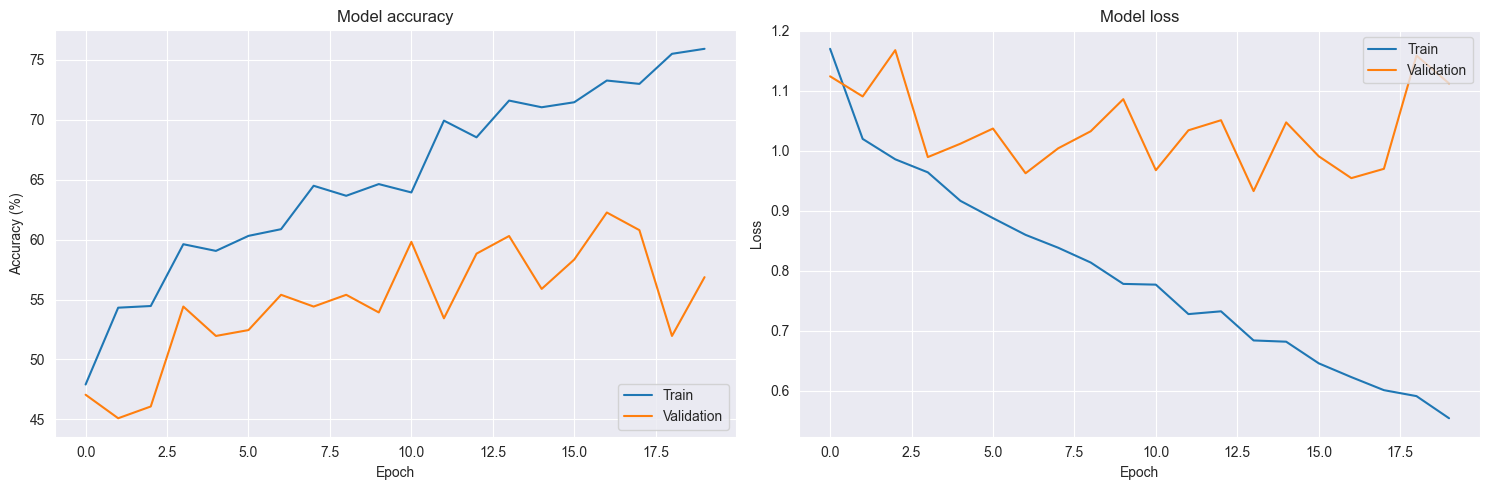

Test Loss: 1.1180, Test Accuracy: 55.24%


Generating predictions: 100%|██████████| 4/4 [00:03<00:00,  1.06it/s]


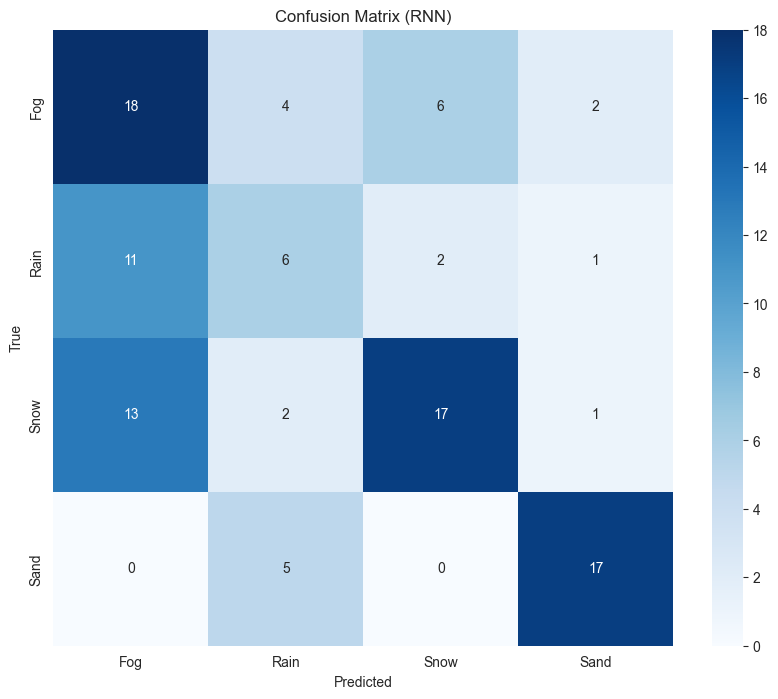


Classification Report (RNN):
              precision    recall  f1-score   support

         Fog       0.43      0.60      0.50        30
        Rain       0.35      0.30      0.32        20
        Snow       0.68      0.52      0.59        33
        Sand       0.81      0.77      0.79        22

    accuracy                           0.55       105
   macro avg       0.57      0.55      0.55       105
weighted avg       0.57      0.55      0.55       105



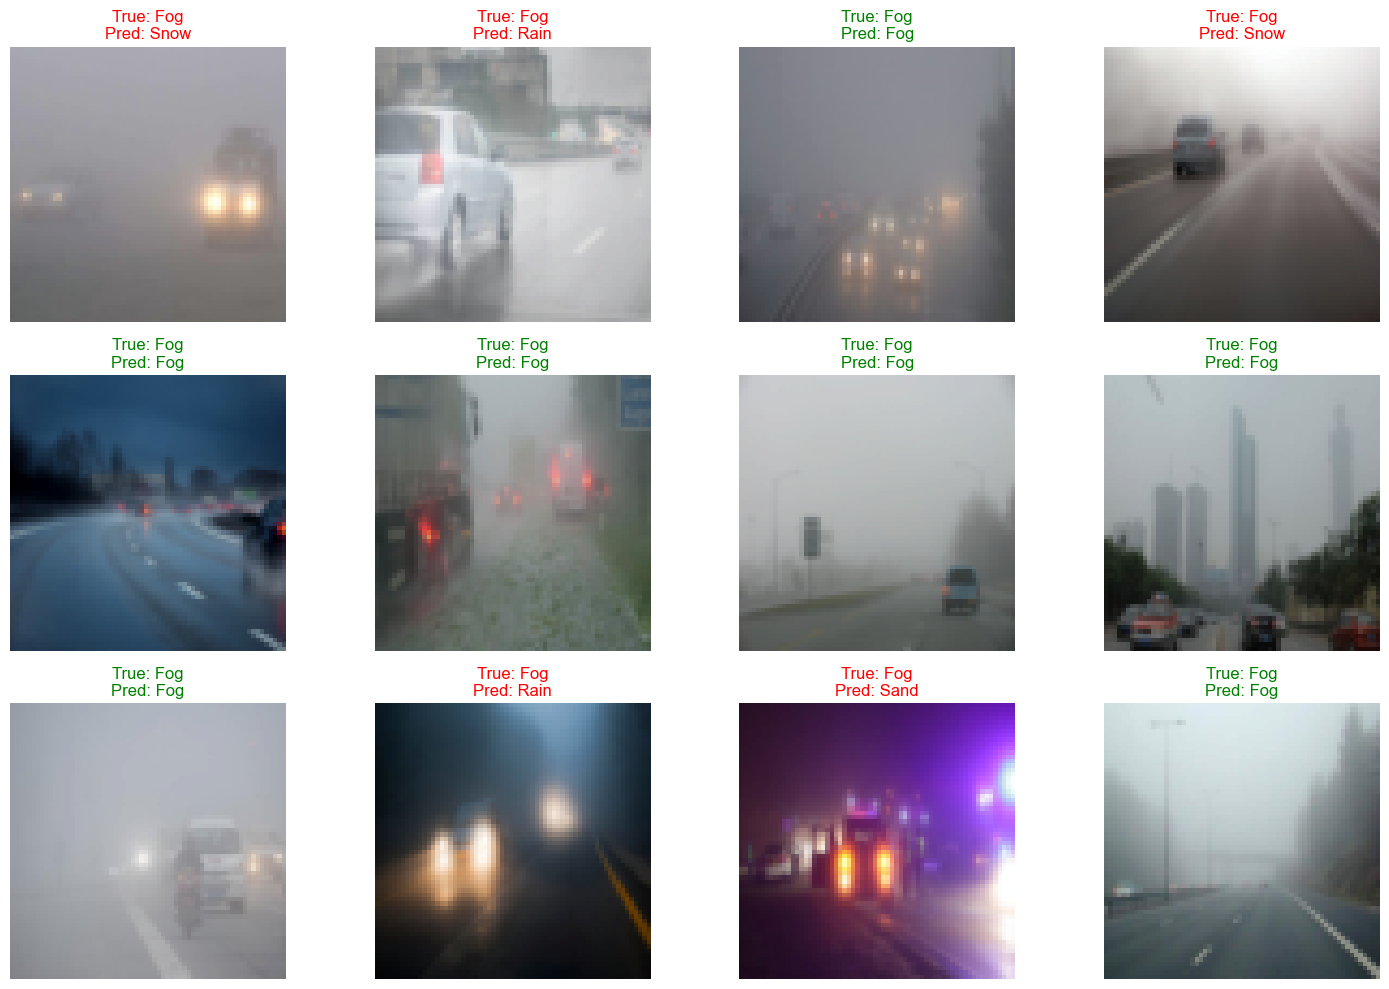

In [18]:

# Main execution
if __name__ == "__main__":
    print("Starting training RNN model...")
    model, history = train_model(model, train_loader, val_loader, criterion, epochs)

    torch.save({
        'model_state_dict': model.state_dict(),
        'classes': classes,
    }, 'weather_classification_rnn_model.pth')
    print("Model saved as 'weather_classification_rnn_model.pth'")

    plot_training_history(history)

    test_loss, test_acc = evaluate_model(model, test_loader, criterion)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

    y_true, y_pred = plot_confusion_matrix(model, test_loader, classes)

    visualize_predictions(model, test_loader, classes)